# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [1]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets

![Iris Flowers](https://github.com/HassanAlgoz/B5/blob/main/content/W3/M1/assets/iris_flowers.png?raw=1)

### Step 1.a Load the data

In [2]:
iris = sklearn.datasets.load_iris(as_frame=True)

# Combine into a single DataFrame for exploration
df = iris.frame
print('Target names:', iris.target_names)
display(df.head())

Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = iris.data    # all 4 features (DataFrame)
y = iris.target  # class labels: 0=setosa, 1=versicolor, 2=virginica

print('X (first 5 rows):')
display(X.head())
print('y (first 5 values):')
print(y.head())

X (first 5 rows):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


y (first 5 values):
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


### Step 2.b print the type of each

In [4]:
print('Type of X:', type(X))
print('Type of y:', type(y))

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [5]:
print('Target dtype  :', y.dtype)
print('Unique values :', y.unique())     # 0, 1, 2
print('Class names   :', iris.target_names.tolist())
print()
print('The target (species) is CATEGORICAL — it represents discrete class labels.')
print('Even though stored as integers (0/1/2), they encode categories, not quantities.')
print('Therefore, the task is CLASSIFICATION.')

Target dtype  : int64
Unique values : [0 1 2]
Class names   : ['setosa', 'versicolor', 'virginica']

The target (species) is CATEGORICAL — it represents discrete class labels.
Even though stored as integers (0/1/2), they encode categories, not quantities.
Therefore, the task is CLASSIFICATION.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print('--- Feature Matrix X ---')
print(f'Shape            : {X.shape}')
print(f'Number of samples: {X.shape[0]}')
print(f'Number of columns: {X.shape[1]}')
print(f'Feature names    : {X.columns.tolist()}')
print()
print('--- Target Vector y ---')
print(f'Shape            : {y.shape}')
print(f'Number of samples: {y.shape[0]}')
print(f'Class distribution:\n{y.value_counts().sort_index()}')

--- Feature Matrix X ---
Shape            : (150, 4)
Number of samples: 150
Number of columns: 4
Feature names    : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

--- Target Vector y ---
Shape            : (150,)
Number of samples: 150
Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
summary = X.agg(['min', 'max', 'median', 'mean', 'std'])
print('Distribution Summary of Features:')
display(summary)

Distribution Summary of Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
min,4.300000,2.000000,1.000000,0.100000
max,7.900000,4.400000,6.900000,2.500000
median,5.800000,3.000000,4.350000,1.300000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

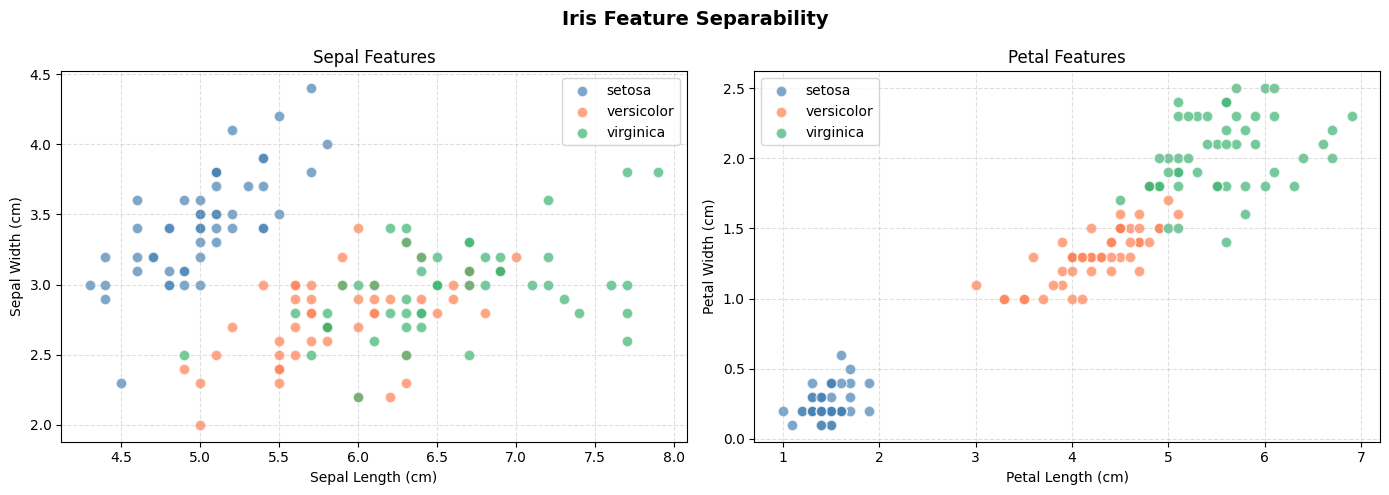

Observation: Petal features show much clearer group separation than sepal features.
Setosa is well-separated in both; versicolor and virginica overlap more in sepal space.


In [8]:
colors  = ['steelblue', 'coral', 'mediumseagreen']
species = iris.target_names

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Sepal features ---
for i, (name, color) in enumerate(zip(species, colors)):
    mask = y == i
    axes[0].scatter(X.loc[mask, 'sepal length (cm)'],
                    X.loc[mask, 'sepal width (cm)'],
                    label=name, color=color, alpha=0.7, edgecolors='white', s=60)
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].set_title('Sepal Features')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- Plot 2: Petal features ---
for i, (name, color) in enumerate(zip(species, colors)):
    mask = y == i
    axes[1].scatter(X.loc[mask, 'petal length (cm)'],
                    X.loc[mask, 'petal width (cm)'],
                    label=name, color=color, alpha=0.7, edgecolors='white', s=60)
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].set_title('Petal Features')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Iris Feature Separability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation: Petal features show much clearer group separation than sepal features.')
print('Setosa is well-separated in both; versicolor and virginica overlap more in sepal space.')

### Step 6. Keep the following in "Steps 7" onwards

1. First model will train on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`

In [9]:
X_sepal = X[['sepal length (cm)', 'sepal width (cm)']]
print('X_sepal shape:', X_sepal.shape)
display(X_sepal.head())

X_sepal shape: (150, 2)


,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`

In [10]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]
print('X_petal shape:', X_petal.shape)
display(X_petal.head())

X_petal shape: (150, 2)


,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


### Step 7. Initialize 2 `LogisticRegression` models

In [11]:
from sklearn.linear_model import LogisticRegression

# max_iter=200 to ensure convergence; random_state for reproducibility
model_sepal = LogisticRegression(max_iter=200, random_state=42)
model_petal = LogisticRegression(max_iter=200, random_state=42)

print('Model 1 (sepal features):', model_sepal)
print('Model 2 (petal features):', model_petal)

Model 1 (sepal features): LogisticRegression(max_iter=200, random_state=42)
Model 2 (petal features): LogisticRegression(max_iter=200, random_state=42)


### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [12]:
from sklearn.model_selection import train_test_split

# Split sepal subset
X_sepal_train, X_sepal_test, y_sepal_train, y_sepal_test = train_test_split(
    X_sepal, y, test_size=0.2, random_state=42, stratify=y
)

# Split petal subset
X_petal_train, X_petal_test, y_petal_train, y_petal_test = train_test_split(
    X_petal, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_sepal_train.shape[0]} samples (80%)')
print(f'Test set size     : {X_sepal_test.shape[0]} samples (20%)')
print()
print('Class distribution in training set:')
print(y_sepal_train.value_counts().sort_index())
print()
print('stratify=y ensures each class is proportionally represented in both splits.')

Training set size : 120 samples (80%)
Test set size     : 30 samples (20%)

Class distribution in training set:
target
0    40
1    40
2    40
Name: count, dtype: int64

stratify=y ensures each class is proportionally represented in both splits.


### Step 9.a Train both models

In [13]:
model_sepal.fit(X_sepal_train, y_sepal_train)
print('Model 1 (sepal) trained successfully!')

model_petal.fit(X_petal_train, y_petal_train)
print('Model 2 (petal) trained successfully!')

Model 1 (sepal) trained successfully!
Model 2 (petal) trained successfully!


### Step 10. Evaluate and compare both models

In [14]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_sepal_pred = model_sepal.predict(X_sepal_test)
y_petal_pred = model_petal.predict(X_petal_test)

acc_sepal = accuracy_score(y_sepal_test, y_sepal_pred)
acc_petal = accuracy_score(y_petal_test, y_petal_pred)

print('=' * 50)
print(f'Model 1 — Sepal Features  Accuracy: {acc_sepal:.4f} ({acc_sepal*100:.1f}%)')
print('=' * 50)
print(classification_report(y_sepal_test, y_sepal_pred, target_names=iris.target_names))

print('=' * 50)
print(f'Model 2 — Petal Features  Accuracy: {acc_petal:.4f} ({acc_petal*100:.1f}%)')
print('=' * 50)
print(classification_report(y_petal_test, y_petal_pred, target_names=iris.target_names))

Model 1 — Sepal Features  Accuracy: 0.7333 (73.3%)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.62      0.50      0.56        10
   virginica       0.58      0.70      0.64        10

    accuracy                           0.73        30
   macro avg       0.74      0.73      0.73        30
weighted avg       0.74      0.73      0.73        30

Model 2 — Petal Features  Accuracy: 0.9667 (96.7%)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

In [15]:
print(f'Sepal model accuracy : {acc_sepal*100:.1f}%')
print(f'Petal model accuracy : {acc_petal*100:.1f}%')
print()

if acc_petal > acc_sepal:
    print('Winner: PETAL features (petal length & petal width) better distinguish iris species.')
    print()
    print('This is consistent with what we saw in Step 5:')
    print('  - Petal features form clearly separated clusters per species.')
    print('  - Sepal features have significant overlap between versicolor and virginica.')
    print('  - Petal measurements are more discriminative for classifying iris flowers.')
else:
    print('Winner: SEPAL features performed better in this split.')

Sepal model accuracy : 73.3%
Petal model accuracy : 96.7%

Winner: PETAL features (petal length & petal width) better distinguish iris species.

This is consistent with what we saw in Step 5:
  - Petal features form clearly separated clusters per species.
  - Sepal features have significant overlap between versicolor and virginica.
  - Petal measurements are more discriminative for classifying iris flowers.


### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

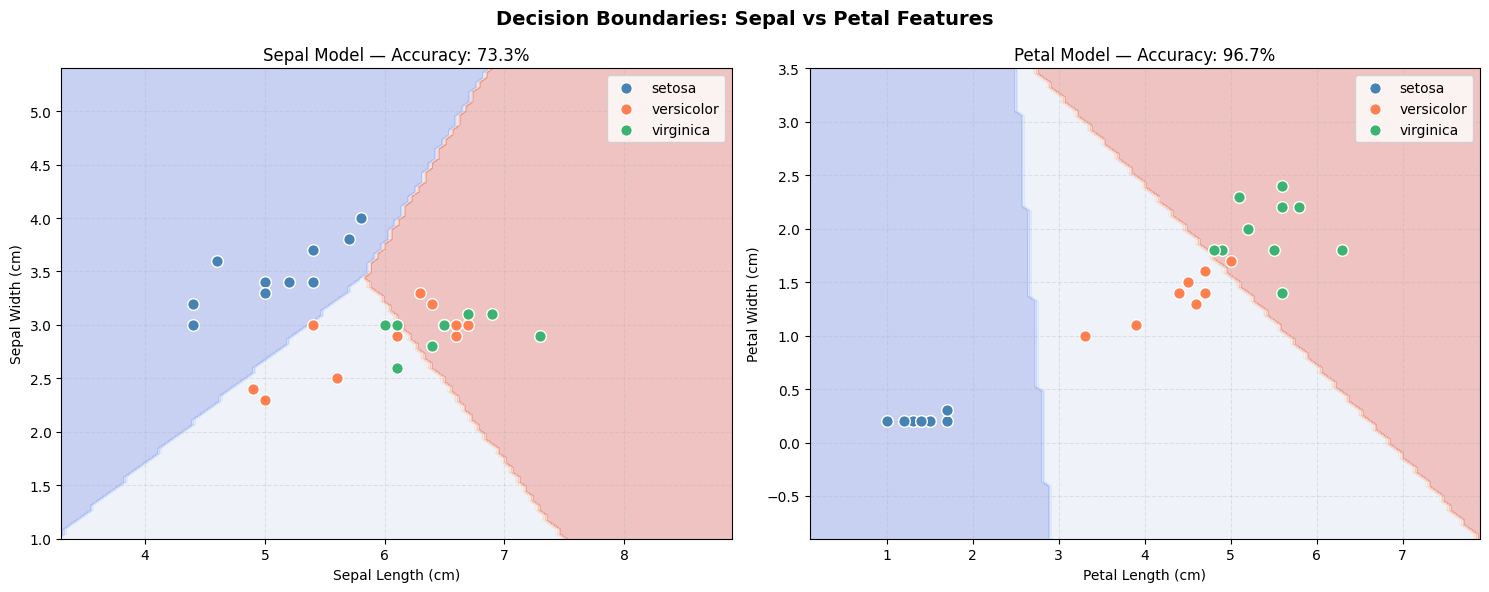

In [16]:
from sklearn.inspection import DecisionBoundaryDisplay

colors  = ['steelblue', 'coral', 'mediumseagreen']
species = iris.target_names

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Sepal decision boundary ---
disp1 = DecisionBoundaryDisplay.from_estimator(
    model_sepal, X_sepal_train,
    response_method='predict',
    cmap='coolwarm', alpha=0.3, ax=axes[0]
)
for i, (name, color) in enumerate(zip(species, colors)):
    mask = y_sepal_test == i
    axes[0].scatter(
        X_sepal_test.loc[mask, 'sepal length (cm)'],
        X_sepal_test.loc[mask, 'sepal width (cm)'],
        label=name, color=color, edgecolors='white', s=70, zorder=2
    )
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].set_title(f'Sepal Model — Accuracy: {acc_sepal*100:.1f}%')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)

# --- Plot 2: Petal decision boundary ---
disp2 = DecisionBoundaryDisplay.from_estimator(
    model_petal, X_petal_train,
    response_method='predict',
    cmap='coolwarm', alpha=0.3, ax=axes[1]
)
for i, (name, color) in enumerate(zip(species, colors)):
    mask = y_petal_test == i
    axes[1].scatter(
        X_petal_test.loc[mask, 'petal length (cm)'],
        X_petal_test.loc[mask, 'petal width (cm)'],
        label=name, color=color, edgecolors='white', s=70, zorder=2
    )
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].set_title(f'Petal Model — Accuracy: {acc_petal*100:.1f}%')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Decision Boundaries: Sepal vs Petal Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()